# Анализ и прогнозирование оттока клиентов фитнес-центра

**Цель исследования** - провести анализ и подготовить план действий по удержанию клиентов фитнес-центра.

**Задачи исследования:**
- спрогнозировать вероятность оттока (на уровне следующего месяца) для каждого клиента;
- сформировать типичные портреты клиентов: выделить несколько наиболее ярких групп и охарактеризовать их основные свойства;
- проанализировать основные признаки, наиболее сильно влияющие на отток;
- выделить целевые группы клиентов;
- предложить меры по снижению оттока;
- определить другие особенности взаимодействия с клиентами;
- разработать рекомендации по повышению качества работы с клиентами.

**Описание данных:**
Файл `/datasets/gym_churn.csv` с данными, которые содержат данные на месяц до оттока и факт оттока на определённый месяц. В файле присутствуют следующие поля:
* Данные клиента за предыдущий до проверки факта оттока месяц:
  - `gender` — пол;
  - `Near_Location` — проживание или работа в районе, где находится фитнес-центр;
  - `Partner` — сотрудник компании-партнёра клуба (сотрудничество с компаниями, чьи сотрудники могут получать скидки на абонемент — в таком случае фитнес-центр хранит информацию о работодателе клиента);
  - `Promo_friends` — факт первоначальной записи в рамках акции «приведи друга» (использовал промо-код от знакомого при оплате первого абонемента);
  - `Phone` — наличие контактного телефона;
  - `Age` — возраст;
  - `Lifetime` — время с момента первого обращения в фитнес-центр (в месяцах).
* Информация на основе журнала посещений, покупок и информация о текущем статусе абонемента клиента:
  - `Contract_period` — длительность текущего действующего абонемента (месяц, 6 месяцев, год);
  - `Month_to_end_contract` — срок до окончания текущего действующего абонемента (в месяцах);
  - `Group_visits` — факт посещения групповых занятий;
  - `Avg_class_frequency_total` — средняя частота посещений в неделю за все время с начала действия абонемента;
  - `Avg_class_frequency_current_month` — средняя частота посещений в неделю за предыдущий месяц;
  - `Avg_additional_charges_total` — суммарная выручка от других услуг фитнес-центра: кафе, спорттовары, косметический и массажный салон.

## Загрузка и предобработка данных

Импортируем необходимые для исследования библиотеки.

In [1]:
#импортируем необходимые библиотеки
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [2]:
!pip install joypy
import joypy

Загрузим данный нам файл с данными.

In [3]:
#загрузим данные файла
try:
    gym_churn = pd.read_csv('/datasets/gym_churn.csv')
except:
    gym_churn = pd.read_csv('https://code.s3.yandex.net/datasets/gym_churn.csv')

Напишем функцию для изучения датафрейма.

In [4]:
#функция для изучения данных датафрейма
def show_info(df):
    print('Первые 5 строк датафрейма:')
    print('-'*80)
    display(df.head())
    print('-'*80)
    print('Размер датафрейма:')
    print('-'*80)
    display(df.shape)
    print('-'*80)
    print('Общая информация о датафрейме:')
    print('-'*80)
    display(df.info())
    print('-'*80)
    print('Статистические данные:')
    print('-'*80)
    display(df.describe())
    print('-'*80)
    print('Наличие пропусков в датафрейме:')
    print('-'*80)
    display(df.isna().sum())
    print('-'*80)
    print('Наличие дубликатов: {}'.format(df.duplicated().sum()))

Изучим всю информацию о нашем датафрейме.

In [5]:
show_info(gym_churn)

Первые 5 строк датафрейма:
--------------------------------------------------------------------------------


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


--------------------------------------------------------------------------------
Размер датафрейма:
--------------------------------------------------------------------------------


(4000, 14)

--------------------------------------------------------------------------------
Общая информация о датафрейме:
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   floa

...

--------------------------------------------------------------------------------
Статистические данные:
--------------------------------------------------------------------------------


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


--------------------------------------------------------------------------------
Наличие пропусков в датафрейме:
--------------------------------------------------------------------------------


gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

--------------------------------------------------------------------------------
Наличие дубликатов: 0


Видим, что необходимо заменить регистр в названиях колонок на нижний и тип данных колонки `Month_to_end_contract` с float на целочисленный. Приступим к обработке.

In [6]:
#приведем названия колонок к нижнему регистру
gym_churn.columns = gym_churn.columns.str.lower()
#выведем названия колонок для проверки
gym_churn.columns

Index(['gender', 'near_location', 'partner', 'promo_friends', 'phone',
       'contract_period', 'group_visits', 'age',
       'avg_additional_charges_total', 'month_to_end_contract', 'lifetime',
       'avg_class_frequency_total', 'avg_class_frequency_current_month',
       'churn'],
      dtype='object')

Изменение регистра в названиях колонок, как видим, прошло успешно.

In [7]:
#заменим тип данных колонки month_to_end_contract на целочисленный
gym_churn['month_to_end_contract'] = gym_churn['month_to_end_contract'].astype(int)
#проверим наши изменения
gym_churn['month_to_end_contract'].dtype

dtype('int64')

Тип данных успешно изменен.

**Вывод по разделу:** 
- В датафрейме 14 колонок и 4000 строк;
- Пропусков и дубликатов в датафрейме не обнаружено;
- Названия колонок для удобства привели к нижнему регистру;
- В колонке `month_to_end_contract` изменили тип данных на целочисленный. В остальных колонках тип данных мовпадал с ожидаемым.

## Исследовательский анализ данных (EDA)

### Статистические данные

Посмотрим статистические данные по всему датасету.

In [8]:
#выведем таблицу со статистическими данными по каждому числовому столбцу
display(gym_churn.describe().T)

,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
near_location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000


Исходя из таблицы, можем сказать, что сильных аномальных выбросов в данных нет. Значения средних и медиан находятся близко к друг другу.

Что можно увидеть из полученной статистики:
- Разделение по полу у клиентов примерно одинаковое
- Примерно 85% клиентов живёт или работает рядом с фитнес-центром
- Около 48% клиентов являются сотрудниками компаний-партнеров фитнес-центра
- Около 30% клиентов пришли в клуб в рамках акции "Приведи друга"
- 90% клиентов оставили свой контактный телефон
- Средняя длительность абонементов - 4,6 месяцев
- Примерно 41% клиентов посещают групповые занятия
- Средний возраст посетителей фитнес-клуба - 29 лет
- Средняя суммарная выручка клуба от дополнительных услуг фитнес-центра составляет примерно 147
- Средний срок до окончания текущего действующего абонемента - 4,3 месяца
- Среднее время с момента первого обращения в фитнес-клуб - 3,7 месяцев
- Средняя частота посещений в неделю с начала действия абонемента примерно 2 раза
- Средняя частота посещений в неделю за предыдущий месяц - 2 раза
- Доля оттока клиентов составляет примерно 27%

### Средние значения признаков с разбивкой по клиентам, которые остались и ушли в отток

Проанализируем средние значения признаков клиентов, оставшихся и попавших в отток.

In [9]:
#выведем средние значения признаков 
gym_churn.groupby('churn').agg('mean').T

churn,0,1
gender,0.510037,0.510839
near_location,0.873086,0.768143
partner,0.534195,0.355325
promo_friends,0.353522,0.183789
phone,0.903709,0.902922
contract_period,5.747193,1.728558
group_visits,0.464103,0.268615
age,29.976523,26.989632
avg_additional_charges_total,158.445715,115.082899
month_to_end_contract,5.283089,1.662582


За 0 принимаются клиенты, которые остались, а за 1 - попавшие в отток.

Что можем сказать:
- Распределение по полу примерно одинаковое
- Клиенты, проживающие или работающие в районе фитнес-центра, отваливаются реже
- Также лучше остаются клиенты, являющиеся сотрудниками компаний-партнеров
- Клиенты, пришедшие по акции "Приведи друга" в 2 раза реже попадают в отток
- Наличие контактного телефона не отличается у двух групп
- У оставшихся клиентов средняя длительность договора больше и составляет около 5 месяцев. При этом у отвалившихся клиентов средняя долительность договора не превышает 1 месяца. Скорее всего такие клиенты и заключают договоры на самый меньший срок.
- Оставшиеся клиенты почти в 2 раза чаще посещают групповые занятия
- Средний возраст оставшихся клиентов 30 лет, а попавших в отток - 27 лет. Не очень большая разница.
- Средняя суммарная выручка от дополнительных услуг клуба у обоих групп отличается не сильно. У оставшихся она составляет примерно 158, а у попавших в отток - примерно 115
- Средний срок окончания договора у оставшихся клиентов, логично, больше, чем у отвалившихся
- Средняя частота посещений в неделю с начал заключения договора у оставшихся клиентов больше и составила 2 раза, в то время как у попавших в отток - 1 раз
- Средняя частота посещений в неделю за предыдущий месяц у оставшихся клиентов также выше.

### Распределение признаков для клиентов, которые ушли в отток и остались

Построим распределения признаков для клиентов с помощью гистограмм.

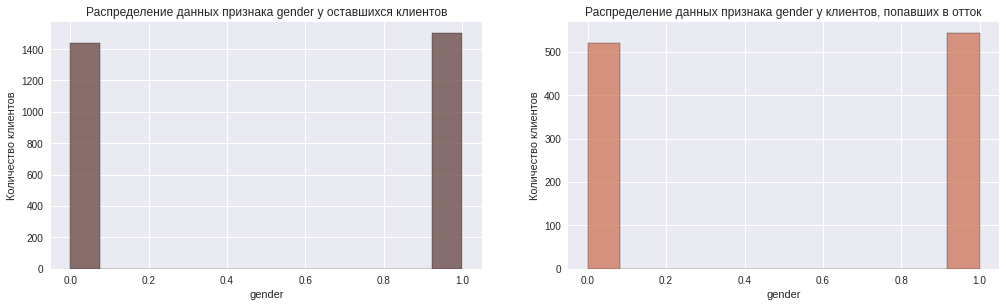

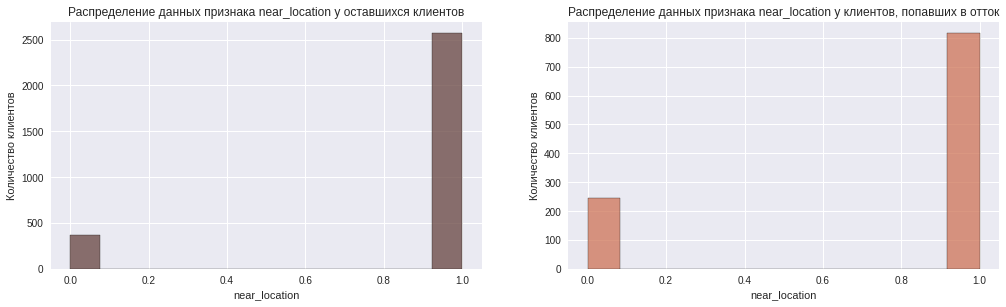

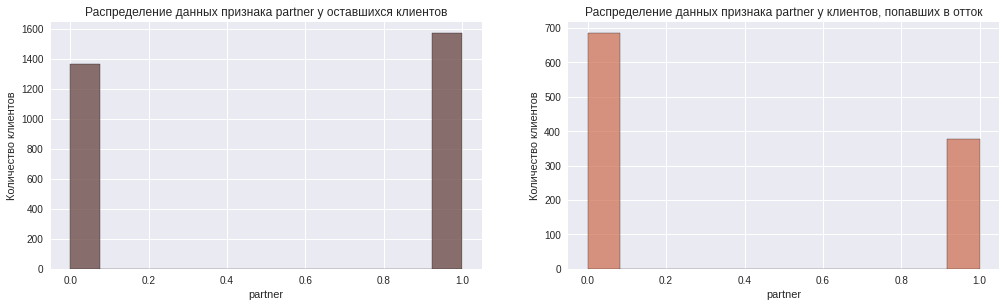

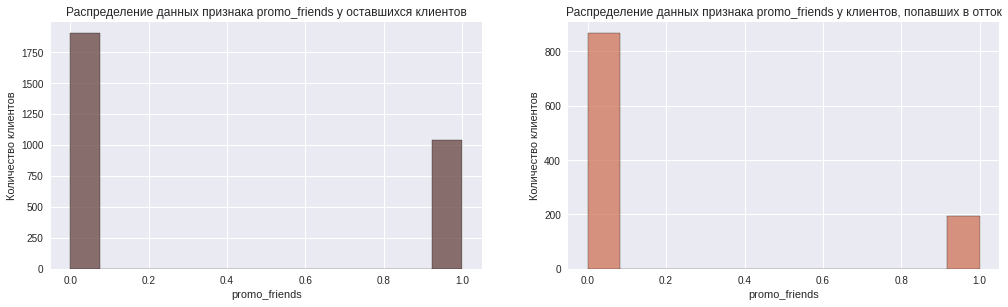

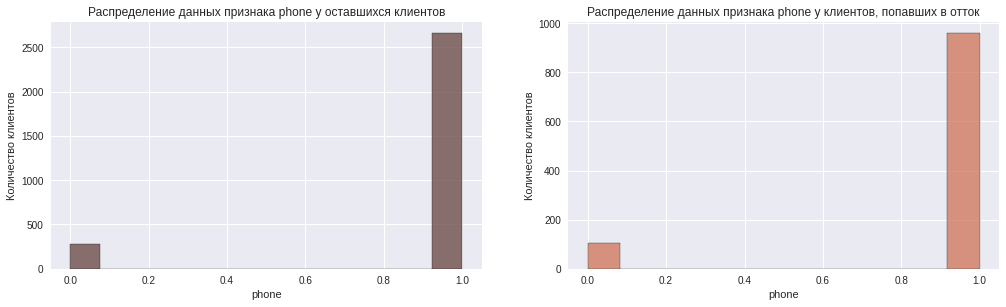

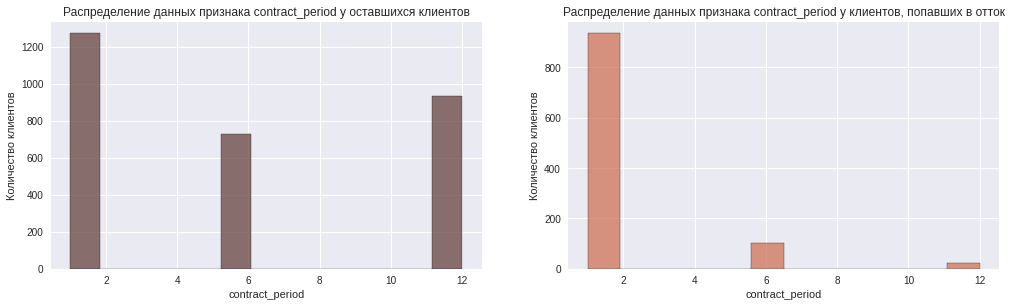

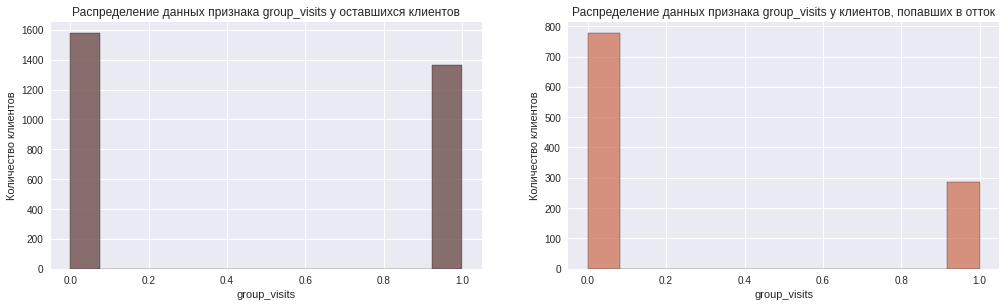

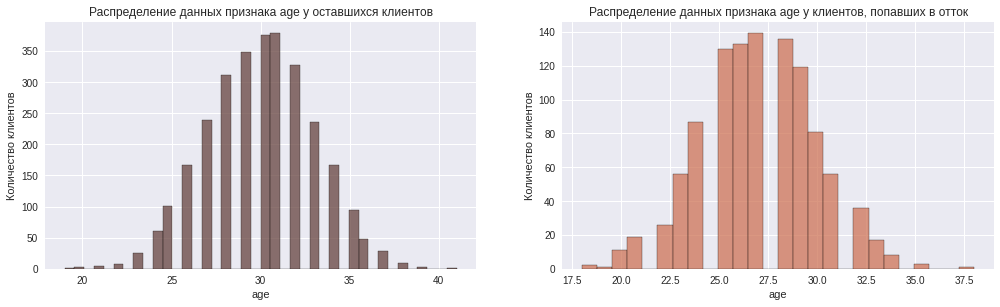

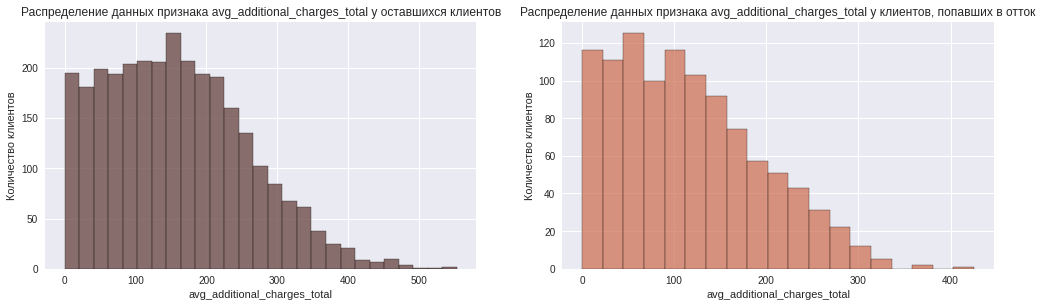

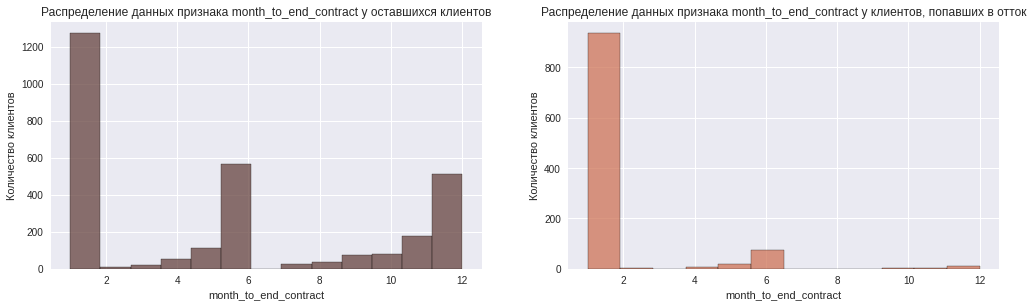

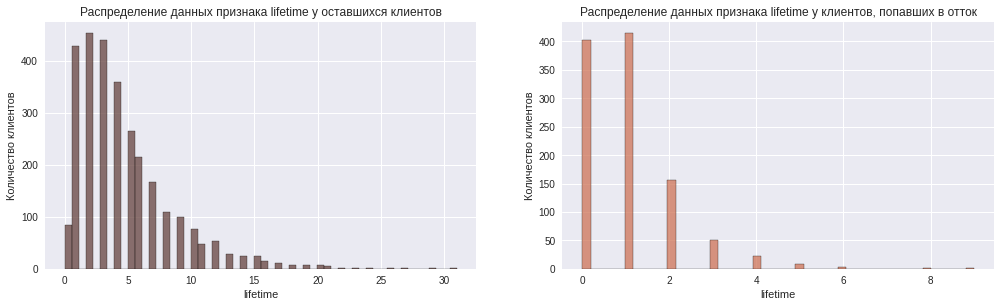

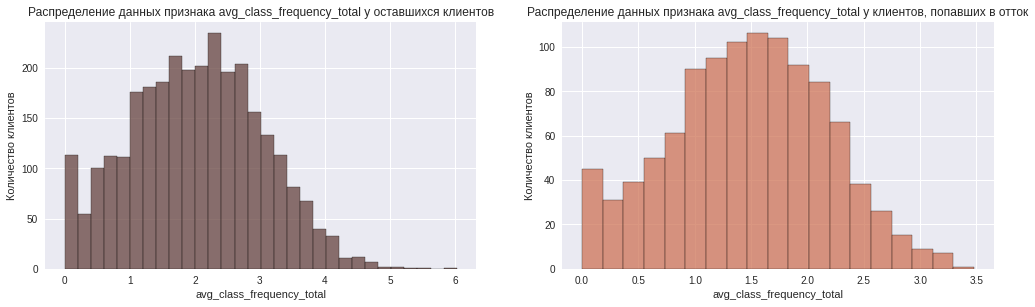

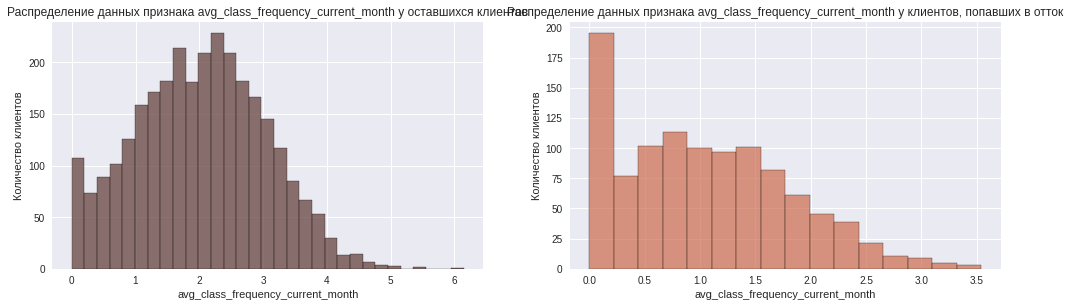

In [10]:
for col in gym_churn.drop('churn', axis=1).columns:
    plt.style.use('seaborn')
    plt.figure(figsize=(17, 10))
    ax1 = plt.subplot(2, 2, 1)
    ax = sns.histplot(gym_churn[gym_churn['churn'] == 0], x=col, color='#66433F', ax=ax1)
    plt.title(f"Распределение данных признака {col} у оставшихся клиентов")
    plt.ylabel('Количество клиентов')
    ax2 = plt.subplot(2, 2, 2)
    ax = sns.histplot(gym_churn[gym_churn['churn'] == 1], x=col, color='#CE7457', ax=ax2)
    plt.title(f"Распределение данных признака {col} у клиентов, попавших в отток")
    plt.ylabel('Количество клиентов')
    plt.show()

На гистограммах 0 (синий цвет) - оставшиеся клиенты, 1 (зеленый цвет) - клиенты попавшие в отток.

Что же сообщают нам гистограммы:
- В отток попадают клиенты в независимости от пола поровну 
- Видим, что клиенты, живущие или работающие рядом с фитнес-центром также активно попадают в отток, как приходящие издалека, хоть и по количеству их меньше. То есть расстояние - не главная причина оттока клиентов.
- Сотрудники компаний-партнеров отваливаются примерно с такой же интенсивностью, как и обычные клиенты. То есть это тоже не является главной причиной оттока.
- Клиенты, пришедшие по акции "Приведи друга" попадают в отток явно реже, чем обычные клиенты. Это не является основной причиной оттока. Вероятно, даже можем предположить, что акция действует успешно.
- Наличие контактного номера также не влияет на отток.
- В основном клиенты приобретают абонементы на 1 месяц. Примерно поровну на 6 и 12 месяцем. При этом, как и предполагалось ранее после 1 месяца посещений очень большая часть клиентов отваливается, после 6 месяцев - отток совсем небольшой, а после 12 месяцев - оттока практически нет - это лояльные клиенты.
- Большая часть клиентов не посещает групповые занятия, в том числе и те, кто попадает в отток.
- Распределение клиентов по возрасту больше похоже на нормальное у обоих категорий. Средний возраст сильно не отличается, у лояльных клиентов - 29 лет, у отвалившихся - 27 лет.
- Распределение трат на дополнительные услуги клуба у клиентов двух категорий похожи и напоминают нормальное. Основные траты распределены от 0 до примерно 150, далее выручка идет на снижение и в редких случаях достигает 500.
- У основной массы клиентов двух категорий до окончания абонемента остался 1 месяц.
- Распределение времени с начала посещения фитнес-центра у двух категорий также похожи. Основная масса клиентов из двух категорий ходит в клуб 1-2 месяца. Но вот лояльные клиенты остаются с в клубе больше года, а попавшие в отток - максимум 5 месяцев.
- Основная масса клиентов двух категорий с начала действия абонемента посещает занятия до 3 раз в неделю.
- В предыдущем месяце лояльные клиенты в основном посещали занятия до 3 раз в неделю, а клиенты, попавшие в отток - до 2 раз.

### Матрица корреляций признаков

Построим матрицу корреляций и посмотрим на зависимость признаков друг от друга.

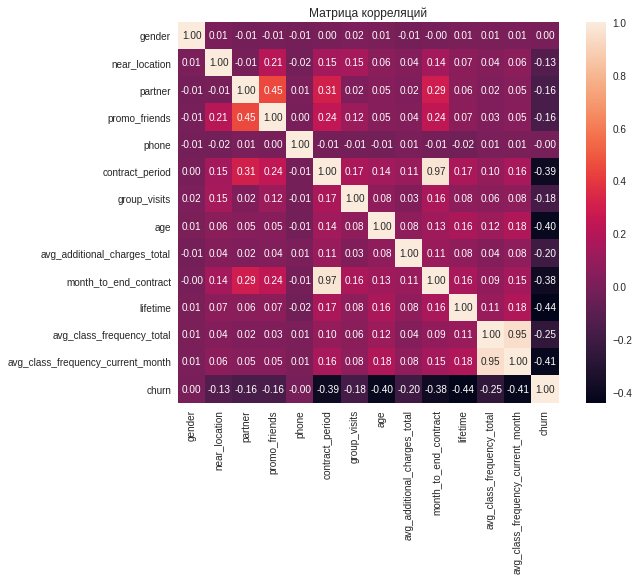

In [11]:
#расчитаем корреляцию
cm = gym_churn.corr()

#строим матрицу
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, square=True, fmt='.2f')
plt.title('Матрица корреляций')
plt.show()

- На матрице не видим явной зависимости оттока от признаков.
- Видна сильная зависимость между длительностью абонемента и временем до окончания абонемента. Также сильная зависимость наблюдается между средней частотой посещения занятий с начала действия абонемента и в предыдущем месяце. Такая сильная зависимость между этими признаками вполне логична, ведь один исходит из другого. Нам, скорее всего, придется удалить один из признаков в каждой паре, так как они фактически показывают одно и то же. Это говорит о мультиколлинеарности признаков.

## Модель прогнозирования оттока клиентов

Нам необходимо построить модель бинарной классификации клиентов, где целевой признак — факт оттока клиента в следующем месяце. Для этого нам нужно:
- избавиться от мультиколлинеарных признаков;
- разбить данные на обучающую и валидационную выборки;
- обучить модель на train-выборке двумя способами: логической регрессией и случайным лесом;
- оценить метрики accuracy, precision и recall для обеих моделей на валидационной выборке и понять, какая модель показала себя лучше.

### Избавляемся от мультиколлинеарности

Ранее мы выяснили, что у нас есть две пары мультиколлинеарных признаков. Чтобы наши модели хорошо себя показали при обучении, один из признаков каждой такой пары нужно удалить.

Из пары признаков `contract_period` и `month_to_end_contract` удалим признак `month_to_end_contract` - срок до окончания текущего действующего абонемента (в месяцах), т.к. он показывает нам меньше информации.

Из пары признаков `avg_class_frequency_current_month` и `avg_class_frequency_total` удалим `avg_class_frequency_current_month` - средняя частота посещений в неделю за предыдущий месяц, по тем же соображениям.

In [12]:
#создадим копию основного датафрейма
gym_churn_cor = gym_churn.copy()
#из нового датафрейма удалим мультиколлинеарные признаки
gym_churn_cor = gym_churn_cor.drop(['month_to_end_contract', 'avg_class_frequency_current_month'], axis=1)
#проверяем
gym_churn_cor.columns

Index(['gender', 'near_location', 'partner', 'promo_friends', 'phone',
       'contract_period', 'group_visits', 'age',
       'avg_additional_charges_total', 'lifetime', 'avg_class_frequency_total',
       'churn'],
      dtype='object')

С мультиколлинеарностью разобрались. Теперь наша модель должна будет работать лучше!

### Разбивка данных на обучающую и валидационную выборки

Разобьем наши данные на обучающую и валидационную выборки и проведем стандартизацию.

За целевую переменную принимаем признак оттока `churn`.

In [13]:
#разделим наши данные на признаки (матрица X) и целевую переменную (y)
X = gym_churn_cor.drop(columns = ['churn'])
y = gym_churn_cor['churn']

#разделяем модель на обучающую и валидационную выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

#приступим к стандартизации
#создадим объект класса StandardScaler и применим его к обучающей выборке
scaler = StandardScaler()
#обучаем scaler и одновременно трансформируем матрицу для обучающей выборки
X_train_st = scaler.fit_transform(X_train)
#применяем стандартизацию к матрице признаков для тестовой выборки
X_test_st = scaler.transform(X_test)

Разбивку на выборки и стандартизацию произвели. Двигаемся дальше.

### Обучаем модель на train выборке 

Обучать нашу модель будем двумя способами:
- логистической регрессией (LogisticRegression())
- случайным лесом (RandomForestClassifier())

После обучения выберем, какая модель успешнее.

In [14]:
#зададим список моделей
models = [
    LogisticRegression(random_state=0),
    RandomForestClassifier(n_estimators=100, random_state=0),
]

#напишем функцию, которая принимает на вход модель и данные и выводит метрики
def make_prediction(m, X_train, y_train, X_test, y_test):
    model = m
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(
        'Accuracy:{:.2f} Precision:{:.2f} Recall:{:.2f} '.format(
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred),
            recall_score(y_test, y_pred),
        )
    )

### Оценка метрик accuracy, precision и recall для обеих моделей на валидационной выборке

Воспользуемся нашей обучающей функцией и выведем метрики. После чего произведем сравнение моделей и посмотрим, какая модель проявила себя лучше.

Метрики, которые мы будем анализировать:
- Accuracy: доля правильных ответов
- Precision: точность (англ. precision)
- Recall: полнота

In [15]:
#напишем цикл, который выводит метрики по списку моделей
for i in models:
    print(i)
    make_prediction(i, X_train_st, y_train, X_test_st, y_test)

LogisticRegression(random_state=0)
Accuracy:0.90 Precision:0.79 Recall:0.81 
RandomForestClassifier(random_state=0)
Accuracy:0.89 Precision:0.79 Recall:0.76 


**Вывод по разделу:** Мы обучили модель методами логистической регрессии и случайным лесом. К слову, обе модели показали себя неплохо. 

- Доля правильных ответов при обучении логисической регрессией 0.9 (высокий показатель), точность - 0.81, минимизация противоположных рисков - 0.8. 
- При обучении случайным лесом для правильных ответов - 0.89, точность - 0.81, минимизация противоположных рисков - 0.76.

По метрикам Accuracy и Recall модель, обученная случайным лесом, немного проигрывает модели, обученной логистической регрессией. **Модель, обученная логистической регрессией, проявила себя лучше.** Хотя, стремиться всегда есть куда!

## Кластеризация клиентов

### Стандартизируем данные

Перед работой с алгоритвами нужно обязательно провести стандартизацию данных. 

In [16]:
#стандартизируем данные без столбца с оттоком
X_sc = scaler.fit_transform(gym_churn_cor.drop(columns=['churn']))

### Строим матрицу расстояний и рисуем дендрограмму

После строим матрицу расстояний на стандартизованной матрице признаков и нарисуйте дендрограмму.

In [17]:
#строим матрицу расстояний на стандартизированной матрице признаков
linked = linkage(X_sc, method='ward')

Перейдем к дендрограмме.

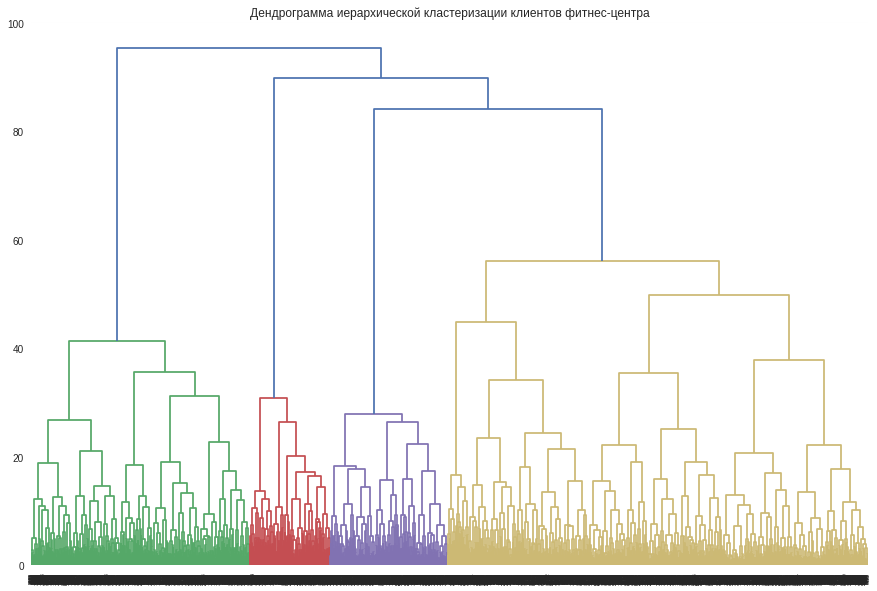

In [18]:
#рисуем дендрограмму
plt.style.use('seaborn')
plt.figure(figsize=(15, 10))
dendrogram(linked, orientation='top')
plt.title('Дендрограмма иерархической кластеризации клиентов фитнес-центра')
plt.show()

На основании простроенной дендрограммы можем явно выделить 4 кластера клиентов. Но будем основываться на ТЗ и считать, что кластеров 5.

### Обучим модель кластеризации на основании алгоритма K-Means и спрогнозируем кластеры клиентов

По нашему ТЗ примем количество кластеров за 5. Теперь проведем обучение модели кластеризации на основании алгоритма K-Means.

In [19]:
#зададим модель k-means с числом кластеров 5 
km = KMeans(n_clusters=5, random_state=0)
#прогнозируем кластеры для наблюдений
labels = km.fit_predict(X_sc)
#сохраним метки кластера в поле нашего датафрейма
gym_churn_cor['cluster_km'] = labels

### Средние значения признаков для кластеров и их распределения

Посчитаем средние значения признаков для кластеров и выведем их на экран.

In [20]:
#выводим статистику по средним значениям наших признаков по кластеру
display(gym_churn_cor.groupby('cluster_km').mean().T)

cluster_km,0,1,2,3,4
gender,0.499109,0.488571,0.505300,0.544202,0.523316
near_location,0.000000,0.995238,1.000000,1.000000,0.862694
partner,0.488414,0.955238,0.238516,0.250287,0.471503
promo_friends,0.076649,0.892381,0.059187,0.079219,0.305699
phone,1.000000,1.000000,1.000000,1.000000,0.000000
contract_period,3.032086,7.660952,2.819788,4.528129,4.777202
group_visits,0.235294,0.458095,0.000000,1.000000,0.427461
age,28.721925,29.543810,28.770318,29.536165,29.297927
avg_additional_charges_total,137.540009,155.861428,143.383993,148.088897,144.208179
lifetime,3.060606,4.380952,3.343640,3.761194,3.940415


Построим распределения признаков для кластеров.

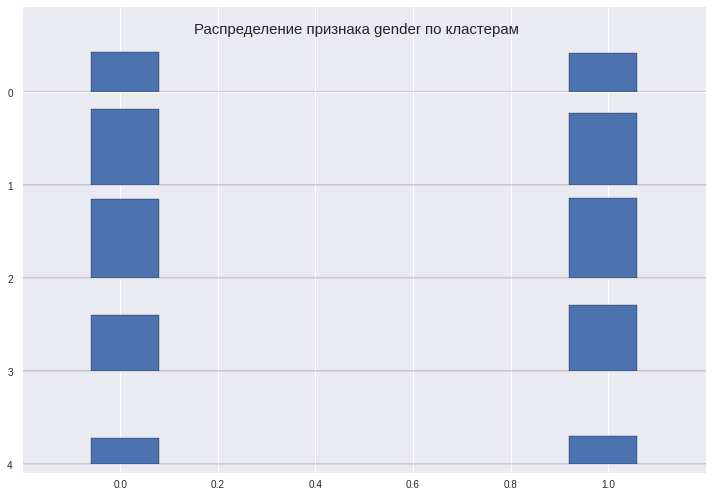

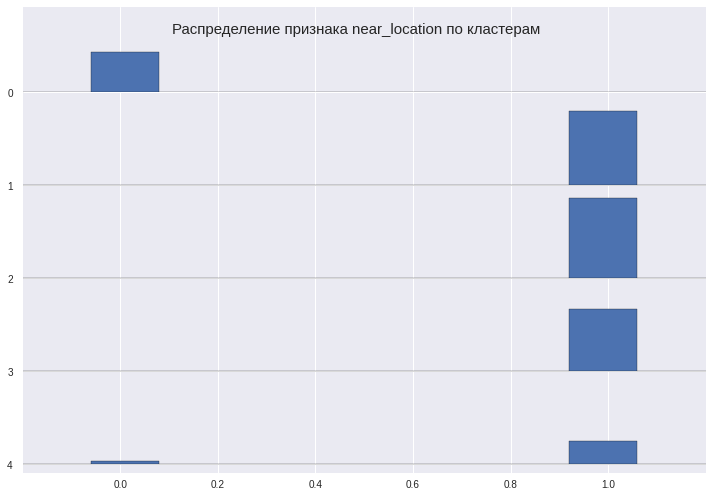

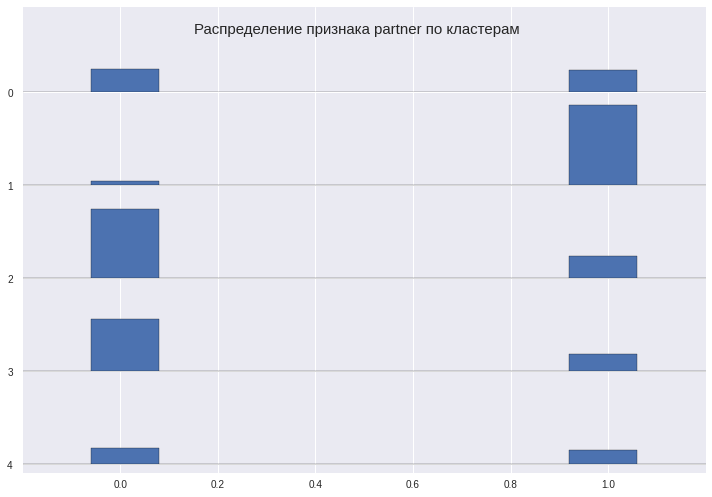

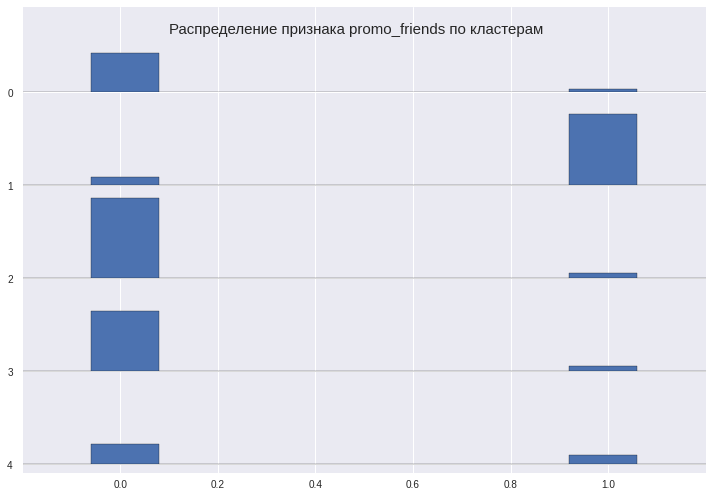

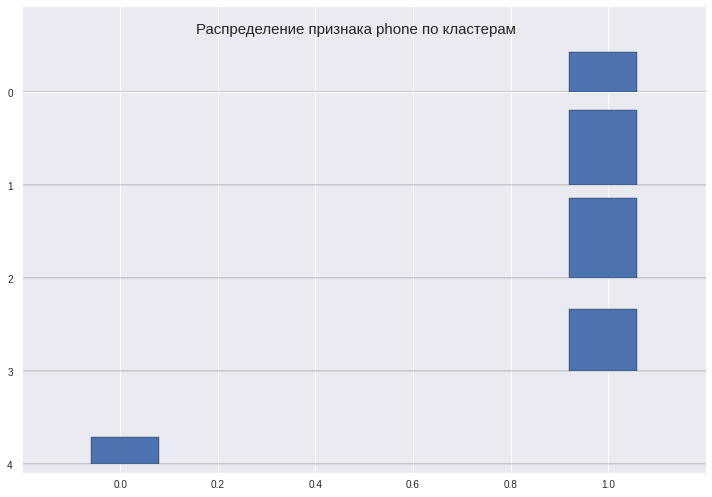

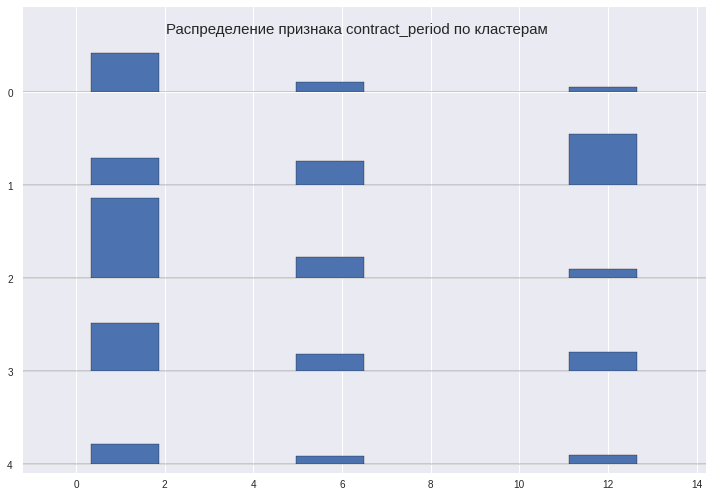

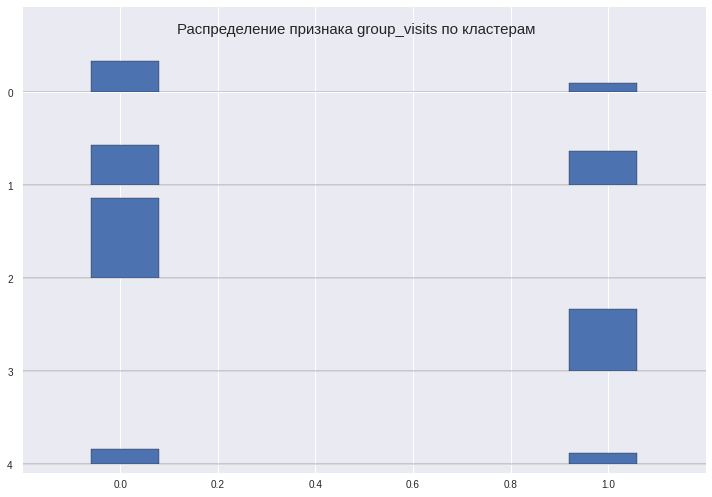

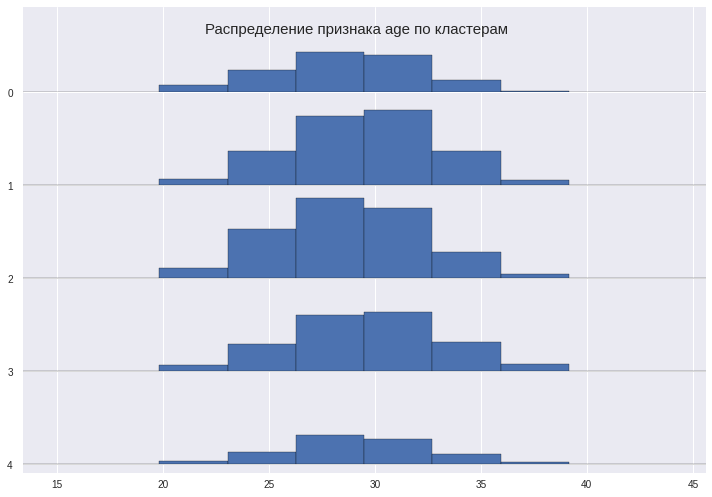

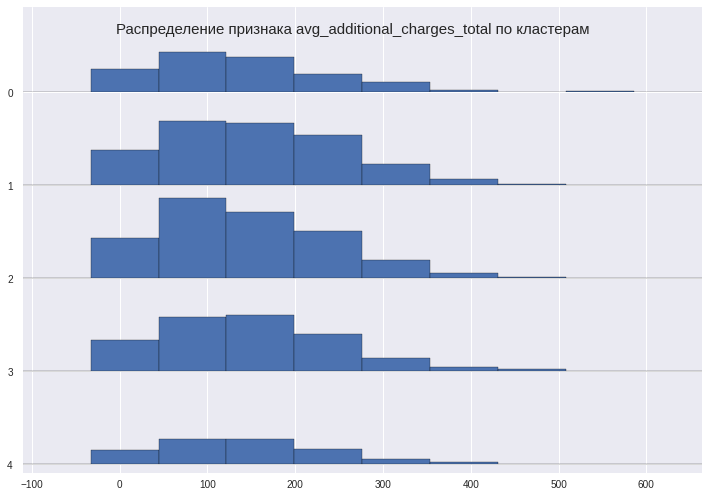

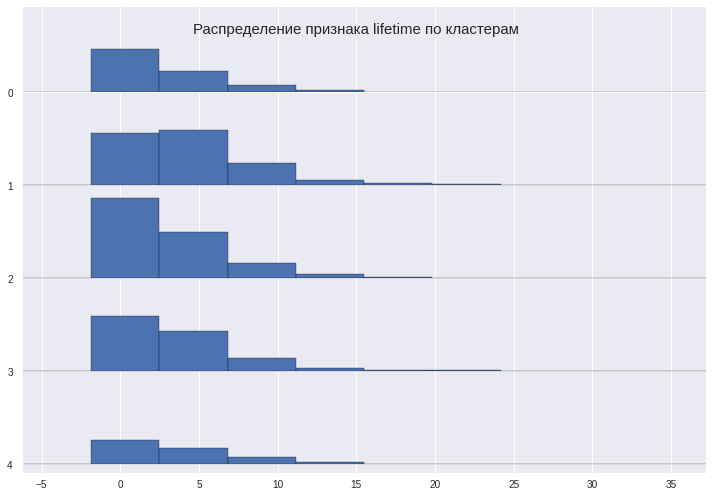

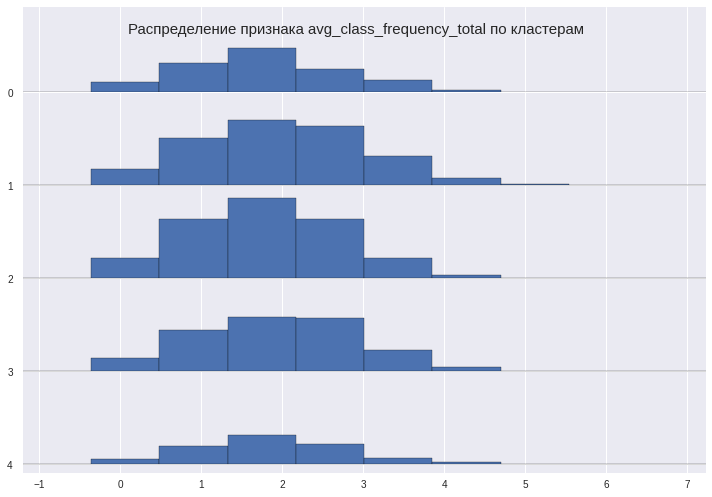

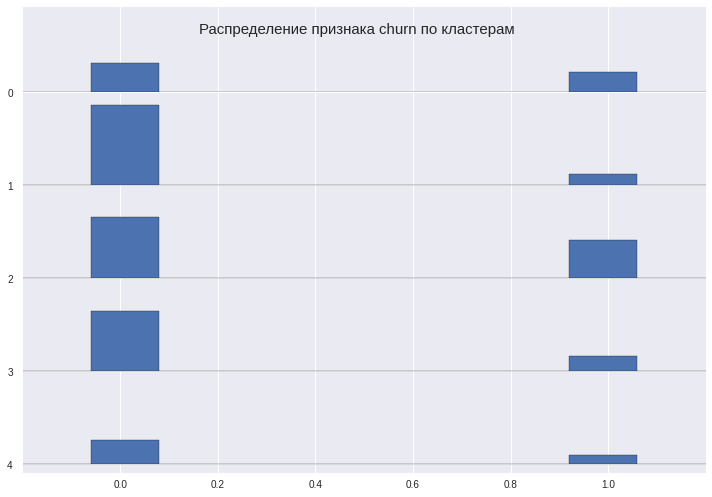

In [21]:
for col in gym_churn_cor.drop('cluster_km', axis=1).columns:
    plt.style.use('seaborn')
    fig, axes = joypy.joyplot(gym_churn_cor, by="cluster_km", column=col, hist=True, overlap=0, grid=True, figsize=(10,7))
    plt.suptitle(f'\nРаспределение признака {col} по кластерам', fontsize = 15)
    plt.show()

Что же представляет из себя каждый кластер?

**Кластер 0:**
- Самый высокий отток - примерно 40%
- Живут или работают далеко от фитнес-центра
- Имеют краткосрочные абонементы 1-3 месяца
- Редко посещают групповые занятия
- **Реже всех посещают клуб** - в среднем 1,8 раз в неделю
- Почти половина клиентов из этого кластера являются сотрудниками компаний-партнеров
- Всего 8% из этих клиентов приходят по акции "Приведи друга"

**Кластер 1:**
- Отток 12% - самый низкий
- Все живут или работают рядом с фитнец-центром
- Имеют **самые долгосрочные абонементы** сроком 1-7 месяцев
- Приносят самую большую выручку
- Чаще всех посещают групповые занятия - 45% клиентов
- Около 95% таких клиентов являются сотрудниками компаний-пратнеров
- 89% пришло по акции "Приведи друга"

**Кластер 2:**
- Отток около 38%
- Все живут или работают поблизости
- Обладатели краткосрочных абонементов 1-3 месяца
- Вообще **не посещают групповые занятия**
- Около 24% клиентов являются сотрудниками компаний-партнеров
- Всего 6% пришли по акции "Приведи друга"

**Кластер 3:**
- Отток - 20%
- Живут или работают вблизи фитнес-центра
- Имеют абонементы сроком 1-4 месяца
- **Абсолютно все посещают групповые занятия**
- Всего 25% являются сотрудниками компаний-партнеров
- Оокло 8% пришло по акции "Приведи друга"

**Кластер 4:**
- Отток около 27%
- 86% клиентов живет или работает поблизости
- Обладатели абонементов сроком 1-5 месяцев
- Почти 43% посещают групповые занятия
- 47% являются сотрудниками компаний-партнеров
- Около 31% пришли по акции "Приведи друга"
- **Нет контакных номеров**

**Вывод:** Самым надежным оказался `кластер 1`. К оттоку более склонны `кластер 0` и `кластер 2`.

## Выводы и рекомендации по работе с клиентами

В работе были проведены исследовательский анализ данных, построены две модели прогнозирования оттока клиентов и произведена кластеризация клиентов для определения поведенческих групп клиентов и отличительных признаков клиентов из оттока.

В ходе работы нами была построена модель с достаточно хорошей точностью, на основании которой можно достаточно точно прогнозировать вероятность оттока по каждому клиенту.

Явных зависимостей факта оттока от одного конкретного признака из рассматриваемых не обнаружено.

**Выводы по имеющимся данным:**
- Разделение по полу у клиентов примерно одинаковое
- Примерно 85% клиентов живёт или работает рядом с фитнес-центром
- Около 48% клиентов являются сотрудниками компаний-партнеров фитнес-центра
- Около 30% клиентов пришли в клуб в рамках акции "Приведи друга"
- 90% клиентов оставили свой контактный телефон
- Средняя длительность абонементов - 4,6 месяцев
- Примерно 41% клиентов посещают групповые занятия
- Средний возраст посетителей фитнес-клуба - 29 лет
- Средняя суммарная выручка клуба от дополнительных услуг фитнес-центра составляет примерно 147
- Средний срок до окончания текущего действующего абонемента - 4,3 месяца
- Среднее время с момента первого обращения в фитнес-клуб - 3,7 месяцев
- Средняя частота посещений в неделю с начала действия абонемента примерно 2 раза
- Средняя частота посещений в неделю за предыдущий месяц - 2 раза
- **Доля оттока клиентов составляет примерно 27%**.

**Выводы на основе отличий признаков у клиентов, попавших в отток и оставшихся:**
- Распределение по полу примерно одинаковое
- Клиенты, проживающие или работающие в районе фитнес-центра, отваливаются реже
- Также лучше остаются клиенты, являющиеся сотрудниками компаний-партнеров
- Клиенты, пришедшие по акции "Приведи друга" в 2 раза реже попадают в отток
- Наличие контактного телефона не отличается у двух групп
- У оставшихся клиентов средняя длительность договора больше и составляет около 5 месяцев. При этом у отвалившихся клиентов средняя долительность договора не превышает 1 месяца. Скорее всего такие клиенты и заключают договоры на самый меньший срок.
- Оставшиеся клиенты почти в 2 раза чаще посещают групповые занятия
- Средний возраст оставшихся клиентов 30 лет, а попавших в отток - 27 лет. Не очень большая разница.
- Средняя суммарная выручка от дополнительных услуг клуба у обоих групп отличается не сильно. У оставшихся она составляет примерно 158, а у попавших в отток - примерно 115
- Средний срок окончания договора у оставшихся клиентов, логично, больше, чем у отвалившихся
- Средняя частота посещений в неделю с начал заключения договора у оставшихся клиентов больше и составила 2 раза, в то время как у попавших в отток - 1 раз
- Средняя частота посещений в неделю за предыдущий месяц у оставшихся клиентов также выше.

Ориентируясь на ТЗ, мы разбили всех клиентов фитнес-центра на 5 кластеров.

**Кластер 0:**
- Самый высокий отток - примерно 40%
- Живут или работают далеко от фитнес-центра
- Имеют краткосрочные абонементы 1-3 месяца
- Редко посещают групповые занятия
- **Реже всех посещают клуб** - в среднем 1,8 раз в неделю
- Почти половина клиентов из этого кластера являются сотрудниками компаний-партнеров
- Всего 8% из этих клиентов приходят по акции "Приведи друга"

**Кластер 1:**
- Отток 12% - самый низкий
- Все живут или работают рядом с фитнец-центром
- Имеют **самые долгосрочные абонементы** сроком 1-7 месяцев
- Приносят самую большую выручку
- Чаще всех посещают групповые занятия - 45% клиентов
- Около 95% таких клиентов являются сотрудниками компаний-пратнеров
- 89% пришло по акции "Приведи друга"

**Кластер 2:**
- Отток около 38%
- Все живут или работают поблизости
- Обладатели краткосрочных абонементов 1-3 месяца
- Вообще **не посещают групповые занятия**
- Около 24% клиентов являются сотрудниками компаний-партнеров
- Всего 6% пришли по акции "Приведи друга"

**Кластер 3:**
- Отток - 20%
- Живут или работают вблизи фитнес-центра
- Имеют абонементы сроком 1-4 месяца
- **Абсолютно все посещают групповые занятия**
- Всего 25% являются сотрудниками компаний-партнеров
- Оокло 8% пришло по акции "Приведи друга"

**Кластер 4:**
- Отток около 27%
- 86% клиентов живет или работает поблизости
- Обладатели абонементов сроком 1-5 месяцев
- Почти 43% посещают групповые занятия
- 47% являются сотрудниками компаний-партнеров
- Около 31% пришли по акции "Приведи друга"
- **Нет контакных номеров**

Определили, что самым надежным оказался `кластер 1`. К оттоку более склонны `кластер 0` и `кластер 2`.

**Рекомендации:**

- Провести акции на групповые занятия
- Сделать онлайн-рассылки о новых акциях и об окончании текущего срока абонемента
- Выдвинуть спецпредложения на дополнительные услуги для новых, а также уже лояльных клиентов
- Проинструктировать отдел продаж о предложении клиентам более долгосрочных абонементов от 6 месяцев и о предложении клиентам дополнительных услуг